# Data Science and Machine Learning Capstone Project Guide

## Overview
This guide breaks down each phase of the capstone project: from data exploration to the final presentation. Follow these steps to ensure a comprehensive and insightful analysis.

## 1. Defining a Research Question and Finding a Dataset

### **Goal:**
Identify a compelling research question and find a suitable dataset to explore it.

### **Steps:**
- **Brainstorm topics:** Choose an area that interests you, preferable in the field of economics and finance. If you insist and I approve, a dataset in another area can be acceptable. 
- **Define a clear research question:** Ensure it's specific and measurable. Examples:
  - Can we predict housing prices based on location and features?
  - What factors most influence customer churn in a subscription service?
  - Can sentiment analysis on social media predict stock price movements?

- **Find a dataset:** Look for reliable, clean datasets. Popular sources include:
  - [Kaggle](https://www.kaggle.com/)
  - [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php)
  - [Google Dataset Search](https://datasetsearch.research.google.com/)
  - Government data portals (e.g., [data.gov](https://www.data.gov/))

- **Evaluate dataset quality:** Check for:
  - Sufficient data points
  - Relevant features
  - Minimal missing data or noise

### **Deliverables:**
- Clear research question
- Dataset link or description
- Brief rationale for dataset choice

---



## 2. Exploratory Data Analysis (EDA)

### **Goal:**
Understand the dataset, identify patterns, and detect anomalies.

### **Steps:**
- **Understand the context:** Research where the data comes from and what it represents.
- **Load the data:** Use `pandas`, `numpy`, or other libraries to load data files.


In [14]:
import pandas as pd
data = pd.read_csv('all_stocks_5yr.csv')

- **Inspect data structure:** Check rows, columns, types, and missing values.

In [16]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


- **Handle missing data:** Options include imputation (`mean`, `median`, or model-based) or removing rows/columns.
- **Identify outliers:** Use boxplots or z-scores.
- **Look for data imbalances:** Particularly important for classification problems.

### **Deliverables:**
- Summary statistics
- Data cleaning report
- Initial observations

---



## 3. Visualizations

### **Goal:**
Communicate insights effectively through visuals.

### **Steps:**
- **Distribution of variables:** Histograms or density plots.
- **Relationships between variables:** Scatter plots, pair plots.
- **Categorical data:** Bar charts, count plots.
- **Time series (if applicable):** Line plots.
- **Geographical data (if applicable):** Maps.

### **Recommended Libraries:**
- `Matplotlib`
- `Seaborn`
- `Plotly` (for interactive charts)

### **Deliverables:**
- Well-labeled, insightful visualizations
- Brief analysis of what each visualization reveals

---



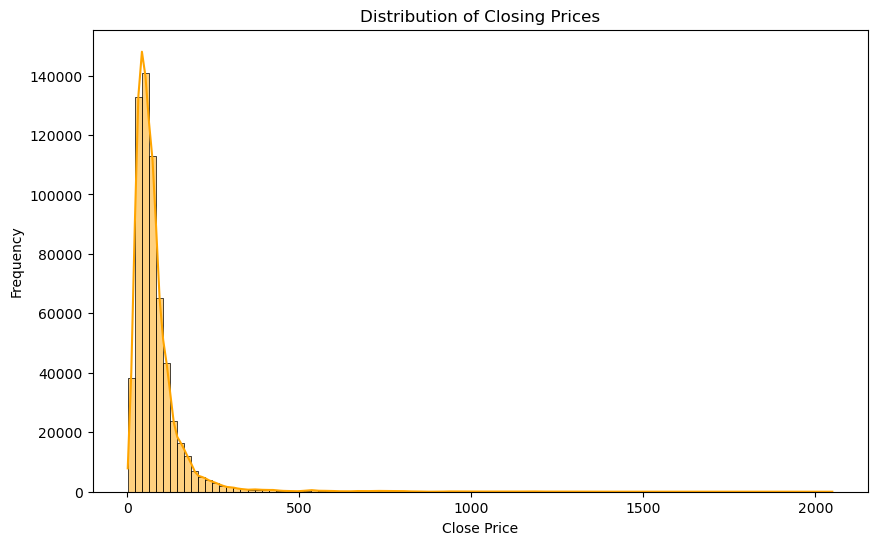

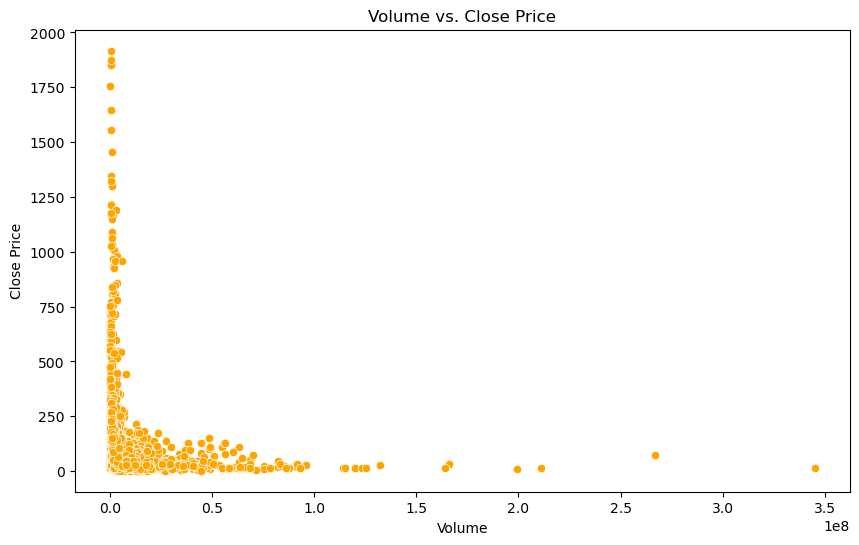

C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_13860\2964678012.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_close.index, y=avg_close.values, palette='Spectral')


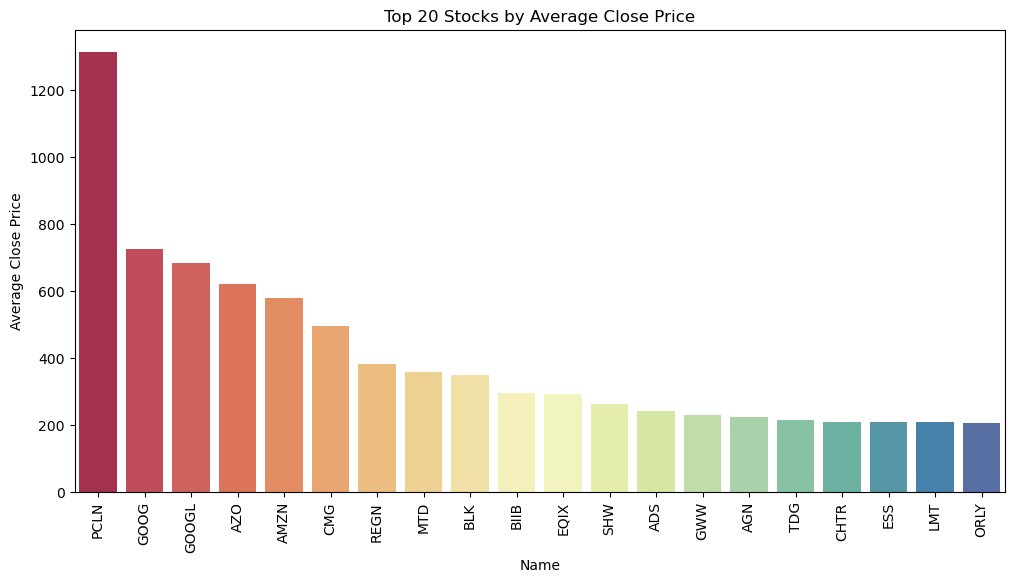

NameError: name 'data_stock' is not defined

<Figure size 1400x600 with 0 Axes>

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data['date'] = pd.to_datetime(data['date'])


plt.figure(figsize=(10, 6))
sns.histplot(data['close'], bins=100, kde=True, color='orange')
plt.title("Distribution of Closing Prices")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='volume', y='close', data=data.sample(10000), color='orange')  # sample for clarity
plt.title("Volume vs. Close Price")
plt.xlabel("Volume")
plt.ylabel("Close Price")
plt.show()


avg_close = data.groupby("Name")["close"].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_close.index, y=avg_close.values, palette='Spectral')
plt.xticks(rotation=90)
plt.title("Top 20 Stocks by Average Close Price")
plt.ylabel("Average Close Price")
plt.show()


sample_stock = 'AAPL' 

plt.figure(figsize=(14, 6))
sns.lineplot(x='date', y='close', data=data_stock, color='orange')
plt.title(f"{sample_stock} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()



## 4. Feature Selection

### **Goal:**
Identify the most informative variables.

### **Steps:**
- **Correlation analysis:** Use `heatmaps` to visualize correlations.


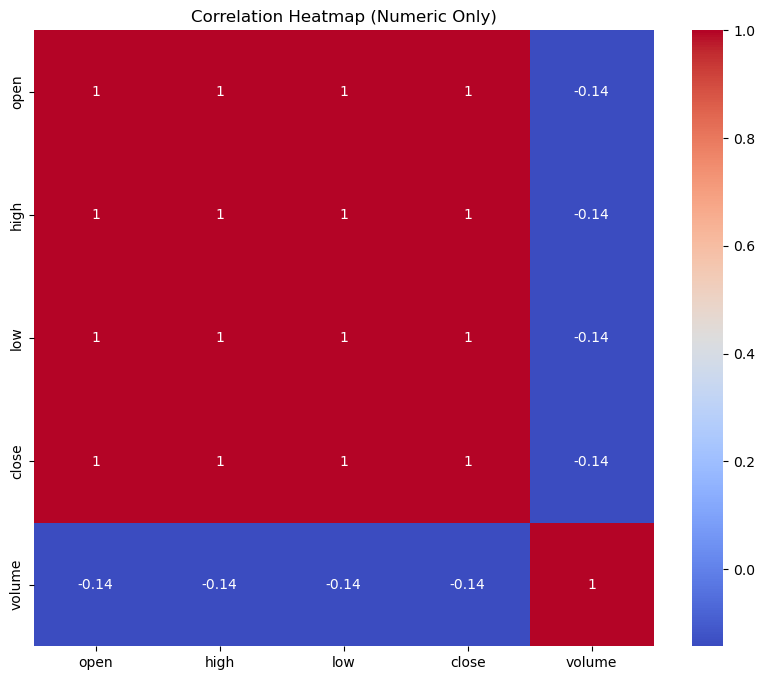

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Only use numeric columns for correlation
numeric_data = data.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Only)")
plt.show()


- **Univariate analysis:** Determine the importance of each feature.
- **Multicollinearity check:** Use Variance Inflation Factor (VIF).

In [28]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numeric columns
numeric_data = data.select_dtypes(include=['number']).dropna()

# Compute VIF
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_data.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_data.values, i) for i in range(numeric_data.shape[1])]

print(vif_data)


  feature           VIF
0    open  31024.772050
1    high  37216.573304
2     low  32898.679019
3   close  34557.905353
4  volume      1.044490


- **Domain knowledge:** Consider whether features make sense practically.
- **Dimensionality reduction:** Use techniques like PCA (Principal Component Analysis) if needed.

### **Deliverables:**
- List of selected features with justification
- Dropped feature report

---



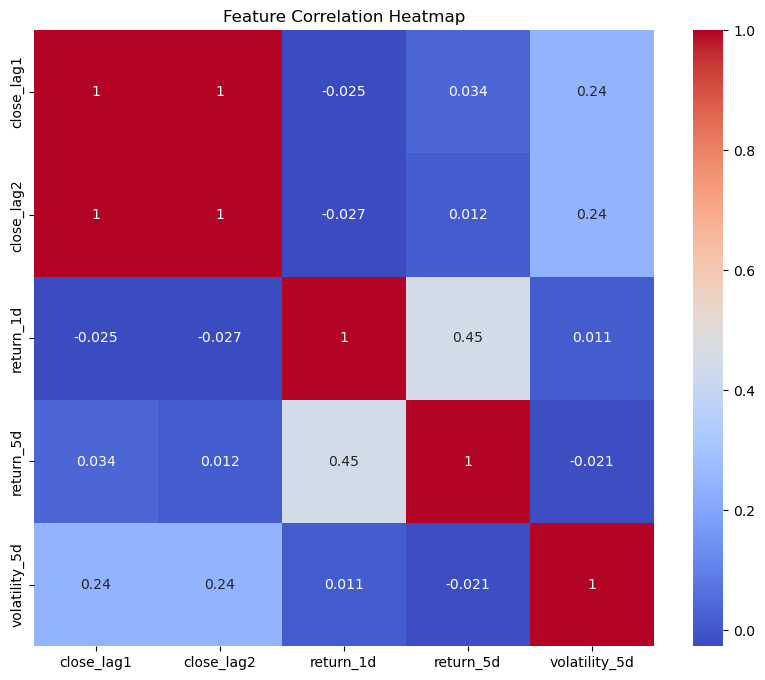


VIF Table:
         feature          VIF
0     close_lag1  6862.826655
1     close_lag2  6843.421878
2      return_1d     1.310763
3      return_5d     1.631371
4  volatility_5d     3.380647


In [30]:
# ---------------- Part 1: Feature Selection ----------------

import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load the dataset
df = pd.read_csv("all_stocks_5yr.csv")

# Filter AAPL data
df_aapl = df[df['Name'] == 'AAPL'].copy()
df_aapl['date'] = pd.to_datetime(df_aapl['date'])
df_aapl.sort_values('date', inplace=True)

# Feature engineering
df_aapl['close_lag1'] = df_aapl['close'].shift(1)
df_aapl['close_lag2'] = df_aapl['close'].shift(2)
df_aapl['return_1d'] = df_aapl['close'].pct_change(1)
df_aapl['return_5d'] = df_aapl['close'].pct_change(5)
df_aapl['volatility_5d'] = df_aapl['close'].rolling(5).std()

# Targets
df_aapl['direction'] = (df_aapl['close'].shift(-1) > df_aapl['close']).astype(int)
df_aapl['month'] = df_aapl['date'].dt.to_period('M')
monthly_avg = df_aapl.groupby('month')['close'].mean().shift(-1)
df_aapl = df_aapl.merge(monthly_avg.rename('monthly_avg_next'), on='month', how='left')

# Drop missing values
df_aapl.dropna(inplace=True)

# Correlation heatmap
features = ['close_lag1', 'close_lag2', 'return_1d', 'return_5d', 'volatility_5d']
plt.figure(figsize=(10, 8))
sns.heatmap(df_aapl[features].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Variance Inflation Factor (VIF)
vif_data = pd.DataFrame()
vif_data["feature"] = features
vif_data["VIF"] = [variance_inflation_factor(df_aapl[features].values, i) for i in range(len(features))]

print("\nVIF Table:")
print(vif_data)


## 5. Building a Predictive Model

### **Goal:**
Build a model that learns from data and predicts future outcomes.

### **Steps:**
1. **Split data:** Train-test split (e.g., 80/20).


In [32]:
from sklearn.model_selection import train_test_split
X = df_aapl[['close_lag1', 'return_1d', 'return_5d', 'volatility_5d']]
y = df_aapl['direction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




2. **Choose algorithms:** Consider linear models, tree-based models, or advanced ones like neural networks.
3. **Train the model:**


In [34]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

4. **Evaluate performance:**
   - Classification: Accuracy, precision, recall, F1-score, ROC-AUC
   - Regression: RMSE, MAE, R^2
5. **Hyperparameter tuning:** Use `GridSearchCV` or `RandomSearchCV`.


In [36]:
#Step4
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20]}
grid = GridSearchCV(model, param_grid)
grid.fit(X_train, y_train)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

#Step5
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train)


best_model = grid.best_estimator_
y_best_pred = best_model.predict(X_test)

print("\nBest Model Evaluation (GridSearchCV):")
print("Accuracy:", accuracy_score(y_test, y_best_pred))
print("Precision:", precision_score(y_test, y_best_pred))
print("Recall:", recall_score(y_test, y_best_pred))
print("F1 Score:", f1_score(y_test, y_best_pred))


Accuracy: 0.46
Precision: 0.5151515151515151
Recall: 0.4892086330935252
F1 Score: 0.5018450184501845

Best Model Evaluation (GridSearchCV):
Accuracy: 0.464
Precision: 0.5182481751824818
Recall: 0.5107913669064749
F1 Score: 0.5144927536231884


6. **Feature importance analysis:** Understand what drove predictions.

### **Deliverables:**
- Model performance metrics
- Model code
- Explanation of algorithm choice

## 5. Presentation

### **Goal:**
Clearly communicate findings, methods, and insights to a diverse audience.

### **Structure:**
- **Introduction:** Define the problem and dataset.
- **EDA summary:** Share key insights and surprising findings.
- **Feature selection:** Justify selected features.
- **Modeling process:** Explain model choices, training, and evaluation.
- **Results:** Show performance metrics and what they mean.
- **Conclusion:** Business insights, recommendations, or next steps.

### **Tips:**
- Use visuals sparingly but effectively.
- Keep explanations clear and jargon-free for non-technical audiences.
- Tell a story: Show how your analysis supports your conclusions.

### **Deliverables:**
- Slide deck (MS PowerPoint)

## Final Notes

- **Documentation matters:** Keep track of assumptions, decisions, and code.
- **Reproducibility:** Ensure anyone can rerun your project with your code.
- **Interpretability:** Always aim to explain your model's behavior, not just predict.

Good luck with the project — and have fun uncovering insights! 🚀

---

